# Proyek Analisis Data: E-Commerce Public Dataset
- **Nama:** Melani Sulistiawati
- **Email:** cdcc008d6x2288@student.devacademy.id
- **ID Dicoding:** CDCC008D6X2288

## Menentukan Pertanyaan Bisnis

- **Pertanyaan 1:** Bagaimana tren jumlah pesanan dan total pendapatan bulanan pada periode Januari 2017 – Agustus 2018, dan bulan mana yang mengalami lonjakan tertinggi?
- **Pertanyaan 2:** Kategori produk apa yang menghasilkan volume penjualan dan pendapatan tertinggi selama periode 2017–2018?
- **Pertanyaan 3:** Bagaimana segmentasi pelanggan berdasarkan RFM Analysis pada periode 2017–2018, dan strategi apa yang dapat meningkatkan jumlah segmen tersebut?
- **Pertanyaan 4:** Negara bagian mana yang menyumbang total pendapatan e-commerce tertinggi pada periode 2017–2018?

## Import Semua Packages/Library yang Digunakan

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import folium
import os
from folium.plugins import HeatMap
import warnings
warnings.filterwarnings('ignore')

# Setting style visualization
sns.set_style('whitegrid')
sns.set_palette('Set2')

## Data Wrangling

### Gathering Data

Dataset E-Commerce merupakan dataset yang terdiri dari beberapa file CSV yang saling terhubung. Berikut adalah daftar file yang akan digunakan:

| File | Deskripsi |
|---|---|
| `orders_dataset.csv` | Data pesanan pelanggan |
| `order_items_dataset.csv` | Detail item dalam setiap pesanan |
| `order_payments_dataset.csv` | Data pembayaran pesanan |
| `order_reviews_dataset.csv` | Ulasan pelanggan |
| `customers_dataset.csv` | Data pelanggan |
| `sellers_dataset.csv` | Data penjual |
| `products_dataset.csv` | Data produk |
| `product_category_name_translation.csv` | Terjemahan nama kategori produk |
| `geolocation_dataset.csv` | Data geolokasi kode pos |

Seluruh dataset dibaca menggunakan `pd.read_csv()` dan disimpan dalam variabel terpisah. Nantinya, semua tabel ini akan digabungkan menjadi satu master dataframe pada tahap cleaning.

In [2]:
# Load semua dataset
orders_df = pd.read_csv('Data/orders_dataset.csv')
order_items_df = pd.read_csv('Data/order_items_dataset.csv')
order_payments_df = pd.read_csv('Data/order_payments_dataset.csv')
order_reviews_df = pd.read_csv('Data/order_reviews_dataset.csv')
customers_df = pd.read_csv('Data/customers_dataset.csv')
sellers_df = pd.read_csv('Data/sellers_dataset.csv')
products_df = pd.read_csv('Data/products_dataset.csv')
category_translation_df = pd.read_csv('Data/product_category_name_translation.csv')
geolocation_df = pd.read_csv('Data/geolocation_dataset.csv')


**Insight:**
- Dataset E-Commerce terdiri dari 9 tabel yang saling berelasi satu sama lain.
- Tabel `orders_df` merupakan tabel pusat yang menghubungkan semua tabel lainnya melalui `order_id` dan `customer_id`.
- Terdapat kolom tanggal di `orders_df` yang perlu dikonversi ke format datetime untuk analisis tren waktu.

### Assessing Data

Pada tahap ini kita akan memeriksa kualitas data dari setiap tabel sebelum melakukan analisis. Pemeriksaan dilakukan menggunakan fungsi `assess_data()` yang kita buat sendiri, mencakup empat aspek berikut:

1. Shape — melihat jumlah baris dan kolom setiap tabel
2. Duplicated rows — mengecek apakah ada baris yang sama persis (duplikat)
3. Missing values — mengidentifikasi kolom mana saja yang memiliki nilai kosong beserta persentasenya
4. Data types — memastikan setiap kolom memiliki tipe data yang sesuai

Fungsi ini dijalankan pada 6 tabel utama: `orders`, `order_items`, `customers`, `products`, `sellers`, dan `geolocation`.

In [3]:
# Fungsi untuk menampilkan ringkasan kualitas data
def assess_data(df, name):
    print(f'\n{'='*50}')
    print(f'Dataset: {name}')
    print(f'Shape: {df.shape}')
    print(f'Duplicated rows: {df.duplicated().sum()}')
    print('\nMissing Values:')
    missing = df.isnull().sum()
    missing_pct = (missing / len(df) * 100).round(2)
    missing_df = pd.DataFrame({'Missing': missing, 'Percentage (%)': missing_pct})
    print(missing_df[missing_df['Missing'] > 0].to_string())
    print('\nData Types:')
    print(df.dtypes)

for df, name in [(orders_df, 'orders'), (order_items_df, 'order_items'),
                 (customers_df, 'customers'), (products_df, 'products'),
                 (sellers_df, 'sellers'), (geolocation_df, 'geolocation')]:
    assess_data(df, name)


Dataset: orders
Shape: (99441, 8)
Duplicated rows: 0

Missing Values:
                               Missing  Percentage (%)
order_approved_at                  160            0.16
order_delivered_carrier_date      1783            1.79
order_delivered_customer_date     2965            2.98

Data Types:
order_id                         object
customer_id                      object
order_status                     object
order_purchase_timestamp         object
order_approved_at                object
order_delivered_carrier_date     object
order_delivered_customer_date    object
order_estimated_delivery_date    object
dtype: object

Dataset: order_items
Shape: (112650, 7)
Duplicated rows: 0

Missing Values:
Empty DataFrame
Columns: [Missing, Percentage (%)]
Index: []

Data Types:
order_id                object
order_item_id            int64
product_id              object
seller_id               object
shipping_limit_date     object
price                  float64
freight_value          fl

In [4]:
# Cek statistik deskriptif order_items
print('Statistik Deskriptif - order_items_df:')
display(order_items_df[['price', 'freight_value']].describe())

# Cek outlier harga produk
print(f'\nHarga produk tertinggi : $ {order_items_df["price"].max():,.2f}')
print(f'Harga produk terendah :$ {order_items_df["price"].min():,.2f}')
print(f'Harga produk median   : $ {order_items_df["price"].median():,.2f}')

Statistik Deskriptif - order_items_df:


,price,freight_value
count,112650.000000,112650.000000
mean,120.653739,19.990320
std,183.633928,15.806405
min,0.850000,0.000000
25%,39.900000,13.080000
50%,74.990000,16.260000
75%,134.900000,21.150000
max,6735.000000,409.680000



Harga produk tertinggi : $ 6,735.00
Harga produk terendah :$ 0.85
Harga produk median   : $ 74.99


**Insight:**

- `orders_df` memiliki missing values pada kolom tanggal pengiriman `(order_delivered_carrier_date dan order_delivered_customer_date)`. Hal ini wajar karena pesanan yang belum terkirim memang tidak memiliki tanggal tersebut.
- `orders_df` juga memiliki seluruh kolom tanggal bertipe `object (teks)`, padahal seharusnya bertipe `datetime`. Ini perlu dikonversi agar bisa digunakan untuk analisis tren waktu.
- `products_df` memiliki missing values pada kolom `product_category_name` dan beberapa kolom dimensi produk `(panjang, lebar, tinggi, berat)`. Kolom yang tidak memiliki nama kategori akan di-drop, sedangkan dimensi yang kosong akan diisi menggunakan nilai median.
- `geolocation_df` memiliki banyak baris duplikat karena satu kode pos bisa memiliki lebih dari satu pasang koordinat. Data ini perlu diagregasi agar setiap kode pos hanya memiliki satu baris.
- Ditemukan outlier ekstrem pada `products_df` di kolom `product_weight_g` dengan nilai 40.425 gram — jauh di atas batas wajar. Outlier ini akan di-drop.
- Outlier juga ditemukan pada kolom price di `order_items_df`, namun tidak di-drop karena bisa jadi mencerminkan produk premium yang tetap relevan untuk analisis.

### Cleaning Data

Berdasarkan hasil assessment di atas, terdapat beberapa masalah yang perlu diperbaiki. Proses cleaning dilakukan dalam urutan berikut:

**Konversi tipe data kolom tanggal**. Lima kolom tanggal di orders_df masih bertipe object. Kita perlu mengonversinya ke tipe datetime menggunakan pd.to_datetime() agar bisa digunakan untuk perhitungan selisih waktu dan pengelompokan per bulan.

In [5]:
# 1. Konversi kolom tanggal ke datetime
date_cols = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]
for col in date_cols:
    orders_df[col] = pd.to_datetime(orders_df[col])

print(orders_df[date_cols].dtypes)

order_purchase_timestamp         datetime64[ns]
order_approved_at                datetime64[ns]
order_delivered_carrier_date     datetime64[ns]
order_delivered_customer_date    datetime64[ns]
order_estimated_delivery_date    datetime64[ns]
dtype: object


Menghapus baris tanpa nama kategori produk pada `products_df` yang tidak memiliki nilai **product_category_name** dihapus menggunakan dropna(). Produk tanpa kategori tidak dapat dikelompokkan secara bermakna dalam analisis.

In [6]:
products_df.dropna(subset=['product_category_name'], inplace=True)

**Deteksi dan penanganan outlier**. Dibuat fungsi detect_outliers() yang menampilkan boxplot horizontal untuk memvisualisasikan sebaran data. 

In [7]:
# Outliers Detection
def detect_outliers(table, added_columns):
    outlier_check = pd.DataFrame(data = table, columns = added_columns)
    fig = sns.set(rc={'figure.figsize':(10,5)})
    fig = sns.boxplot(x="value", y="variable", data=pd.melt(outlier_check), orient="h")
    return fig

<Axes: xlabel='value', ylabel='variable'>

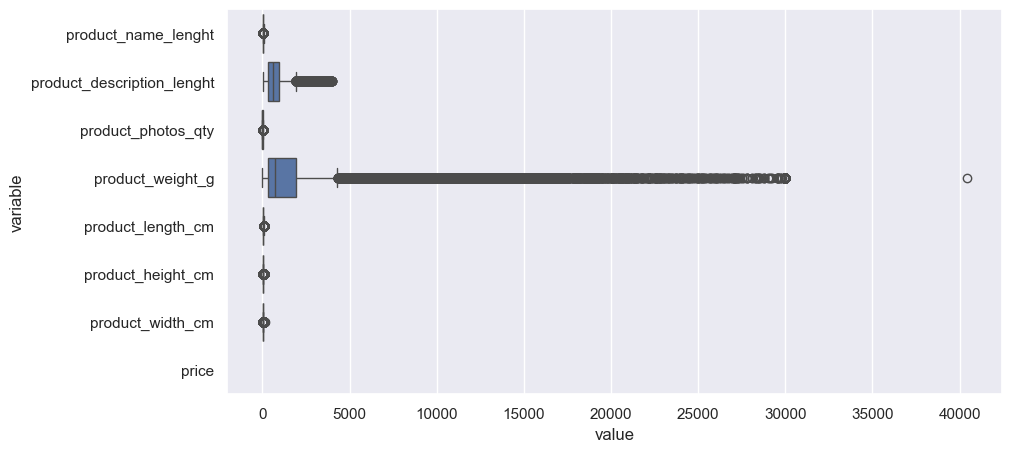

In [8]:
# Outliers detection on products_df
columns = ['product_name_lenght', 'product_description_lenght',
           'product_photos_qty', 'product_weight_g',
           'product_length_cm', 'product_height_cm',
           'product_width_cm', 'price']
detect_outliers(products_df, columns)

Ditemukan bahwa pada product_weight_g terdapat outlier yang sangat jauh dari kumpulan data. Karena berat dari produk ini tidak memuat informasi yang signifikan untuk analisis sales, maka akan dihilangkan. Caranya adalah dengan mencari nilai dari outliers tersebut kemudian akan di-drop.

<Axes: xlabel='value', ylabel='variable'>

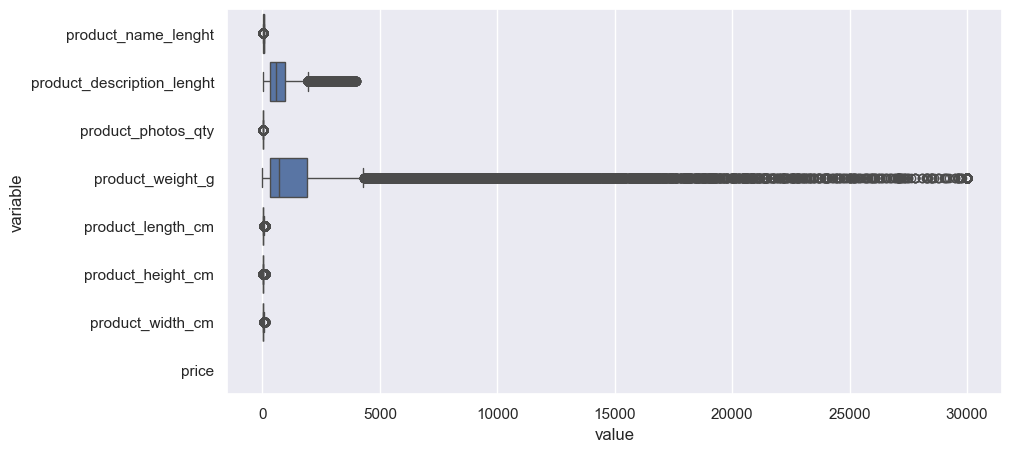

In [9]:
# Mencari nilai outlier
products_df['product_weight_g'].max()
# Drop
products_df.drop(products_df[products_df["product_weight_g"]==40425.0].index, inplace=True)

# Cek lagi
detect_outliers(products_df, columns)

Outlier berhasil untuk diatasi pada df_products. Kemudian, dilihat juga outliers pada df_order karena terdapat variabel numerik pada dataframe tersebut, yaitu price dan freight_value.

<Axes: xlabel='value', ylabel='variable'>

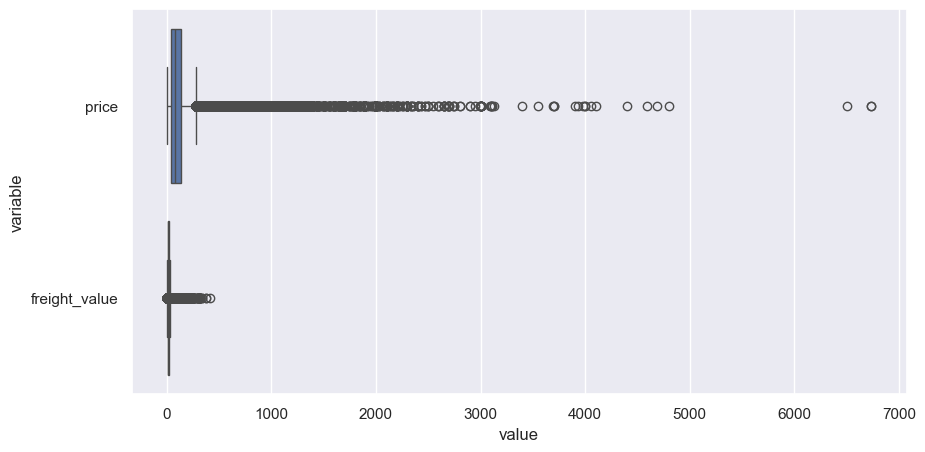

In [10]:
columns = ['price', 'freight_value']
detect_outliers(order_items_df, columns)

**Menambahkan kategori produk yang hilang dan menerjemahkan ke bahasa Inggris**. Saat melakukan left join antara products_df dan category_translation_df, ditemukan dua kategori yang tidak memiliki padanan bahasa Inggris, yaitu pc_gamer dan portateis_cozinha_e_preparadores_de_alimentos. Keduanya ditambahkan secara manual ke tabel terjemahan sebelum join dilakukan ulang. Setelah join, kolom nama kategori bahasa Portugis dihapus dan diganti dengan versi bahasa Inggris.

In [11]:
#  Left join agar nama kategori menjadi bahasa Inggris.
# Namun, perlu dicek dengan outer join apakah ada kategori yang belum tercatat di kedua bahasa
left_join_product = products_df.merge(category_translation_df, how='left', on='product_category_name', indicator=True)
left_outer = left_join_product[left_join_product['_merge'] == 'left_only']

# Terdapat dua products yg belum ada di table product category
left_outer['product_category_name'].unique()

array(['pc_gamer', 'portateis_cozinha_e_preparadores_de_alimentos'],
      dtype=object)

Dua kategori yang tidak ada pada kedua tabel bisa didapatkan dari outer hasil join. Dua kategori itu adalah ‘pc_gamer’ dan ‘portateis_cozinha_e_preparadores_de_alimentos’. Kemudian, akan di-assign kedua kategori tersebut agar tidak hilang pada saat left join. Karena portateis cozinha e preparadores de alimentos berarti peralatan memasak portable, maka akan diberi nama kategori berbahasa Inggris-nya adalah ‘portable kitchen food preparation’.

In [12]:
# Menambahkan daftar products yang belum ada ke dalam table products_category
category_translation_df.loc[len(category_translation_df.index)] = ['pc_gamer','pc_gamer'] 
category_translation_df.loc[len(category_translation_df.index)] = ['portateis_cozinha_e_preparadores_de_alimentos','portable kitchen food preparation']

In [13]:
# Setelah table product category lengkap maka melakukan join table products dengan product_category
df_products2 = products_df.merge(category_translation_df, how='left', on='product_category_name')
df_products2

# Drop kategori bahasa spanyol dan rename
df_products2.drop('product_category_name', axis=1, inplace=True)
df_products2.rename(columns = {'product_category_name_english':'product_category_name'}, inplace = True)

Mengisi missing values dimensi produk dengan median. Kolom dimensi produk (nama, deskripsi, foto, berat, panjang, lebar, tinggi) yang masih kosong diisi menggunakan nilai median masing-masing kolom. Median dipilih karena lebih tahan terhadap pengaruh outlier dibandingkan mean.

In [14]:
#Isi dimensi produk dengan median krena lebig robust terhadap outlier dibandingkan mean
dim_cols = ['product_name_lenght', 'product_description_lenght', 'product_photos_qty',
           'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm']
for col in dim_cols:
    df_products2[col].fillna(df_products2[col].median(), inplace=True)

print('Missing values df_products2 setelah cleaning:')
print(df_products2.isnull().sum())

Missing values df_products2 setelah cleaning:
product_id                    0
product_name_lenght           0
product_description_lenght    0
product_photos_qty            0
product_weight_g              0
product_length_cm             0
product_height_cm             0
product_width_cm              0
product_category_name         0
dtype: int64


Menghapus duplikat geolocation dengan agregasi `geolocation_df` diagregasi menggunakan `groupby()` berdasarkan kode pos. Setiap kode pos diwakili oleh rata-rata koordinat latitudnya dan longitudnya, serta nilai `first()` untuk kota dan negara bagian. Hasilnya, jumlah baris berkurang drastis dari ratusan ribu menjadi ribuan entri unik.

In [15]:
#Agregasi geolocation - ambil rata-rata koordinat per zip_code
geolocation_clean = geolocation_df.groupby('geolocation_zip_code_prefix').agg(
    lat=('geolocation_lat', 'mean'),
    lng=('geolocation_lng', 'mean'),
    city=('geolocation_city', 'first'),
    state=('geolocation_state', 'first')
).reset_index()

print(f'Geolocation sebelum agregasi : {geolocation_df.shape[0]:,} baris')
print(f'Geolocation setelah agregasi : {geolocation_clean.shape[0]:,} baris')

Geolocation sebelum agregasi : 1,000,163 baris
Geolocation setelah agregasi : 19,015 baris


Filter hanya pesanan berstatus delivered. Analisis hanya difokuskan pada pesanan yang sudah sampai ke pelanggan `(order_status == 'delivered')`. Pesanan yang dibatalkan, dalam proses, atau tidak terselesaikan dikeluarkan dari dataset.

In [16]:
#Filter hanya pesanan yang delivered
orders_delivered = orders_df[orders_df['order_status'] == 'delivered'].copy()
print(f'Total orders          : {len(orders_df):,}')
print(f'Orders delivered      : {len(orders_delivered):,}')

Total orders          : 99,441
Orders delivered      : 96,478


Menggabungkan semua tabel menjadi master dataframe. Semua tabel yang sudah dibersihkan digabungkan secara bertahap menggunakan `merge()` dengan metode left join, dimulai dari `orders_delivered` sebagai tabel utama. Ditambahkan pula kolom turunan waktu `(order_year, order_month, order_year_month)` untuk memudahkan analisis tren.

In [17]:

# Buat master dataframe untuk analisis
master_df = orders_delivered.merge(order_items_df, on='order_id', how='left')
master_df = master_df.merge(customers_df, on='customer_id', how='left')
master_df = master_df.merge(df_products2[['product_id', 'product_category_name']], on='product_id', how='left')
master_df = master_df.merge(order_payments_df.groupby('order_id')['payment_value'].sum().reset_index(), on='order_id', how='left')

# Tambah kolom waktu
master_df['order_year']       = master_df['order_purchase_timestamp'].dt.year
master_df['order_month']      = master_df['order_purchase_timestamp'].dt.month
master_df['order_year_month'] = master_df['order_purchase_timestamp'].dt.to_period('M')

print(f'\nShape master_df: {master_df.shape}')
display(master_df.head(3))


Shape master_df: (110197, 23)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,product_id,...,freight_value,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,product_category_name,payment_value,order_year,order_month,order_year_month
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,1,87285b34884572647811a353c7ac498a,...,8.72,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,housewares,38.71,2017,10,2017-10
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,1,595fac2a385ac33a80bd5114aec74eb8,...,22.76,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,perfumery,141.46,2018,7,2018-07
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,1,aa4383b373c6aca5d8797843e5594415,...,19.22,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,auto,179.12,2018,8,2018-08


Menyimpan sample data untuk dashboard. Dari master dataframe yang berisi ratusan ribu baris, diambil sampel sebanyak 50.000 baris menggunakan `sample()` dan disimpan sebagai  `main_data.csv` di folder `dashboard/`. File inilah yang nantinya digunakan oleh aplikasi Streamlit.

In [21]:
# Buat folder penyimpanan hasil untuk dashboard
os.makedirs('dashboard', exist_ok=True)

# Sampling dulu untuk mempercepat proses di dashboard
sample_df = master_df.sample(50000)

# Simpan hasil ke CSV untuk dashboard
sample_df.to_csv('dashboard/main_data.csv', index=False)

print('File saved successfully to dashboard/main_data.csv')

File saved successfully to dashboard/main_data.csv


**Insight:**
- Setelah proses cleaning, 97.0% dari total pesanan berstatus `delivered` dan siap dianalisis.
- Duplikat pada `geolocation_df` berhasil direduksi menjadi entri unik per kode pos.
- Master dataframe berhasil dibuat dengan menggabungkan seluruh tabel relevan.

## Exploratory Data Analysis (EDA)

### Explore Tren Pesanan dan Pendapatan per Bulan

In [21]:
# Agregasi pesanan dan pendapatan per bulan
monthly_orders = master_df.groupby('order_year_month').agg(
    total_order=('order_id', 'nunique'),
    total_pendapatan=('payment_value', 'sum')
).reset_index()
monthly_orders['order_year_month'] = monthly_orders['order_year_month'].astype(str)

# Filter rentang data yang valid (Sep 2016 - Agt 2018)
monthly_orders = monthly_orders[(monthly_orders['order_year_month'] >= '2017-01') &
                                  (monthly_orders['order_year_month'] <= '2018-08')]

print(f'Rentang data: {monthly_orders["order_year_month"].min()} s.d. {monthly_orders["order_year_month"].max()}')
print(f'Total orders keseluruhan : {monthly_orders["total_order"].sum():,}')
print(f'Total pendapatan keseluruhan: $ {monthly_orders["total_pendapatan"].sum():,.2f}')
display(monthly_orders.head(10))

Rentang data: 2017-01 s.d. 2018-08
Total orders keseluruhan : 96,211
Total pendapatan keseluruhan: $ 19,714,393.88


,order_year_month,total_order,total_pendapatan
3,2017-01,750,176491.49
4,2017-02,1653,325782.66
5,2017-03,2546,505735.83
6,2017-04,2303,456108.32
7,2017-05,3546,701313.60
8,2017-06,3135,585400.98
9,2017-07,3872,716069.98
10,2017-08,4193,842689.94
11,2017-09,4150,996279.59
12,2017-10,4478,998609.62


### Explore Kategori Produk Terlaris

In [22]:
# Top 10 kategori berdasarkan jumlah item terjual
top_category = master_df.groupby('product_category_name').agg(
    total_item=('order_id', 'count'),
    total_pendapatan=('price', 'sum')
).reset_index().sort_values('total_item', ascending=False).head(10)

print('Top 10 Kategori Berdasarkan Jumlah Item:')
display(top_category)

# Top 10 kategori berdasarkan pendapatan
top_category2 = master_df.groupby('product_category_name').agg(
    total_items=('order_id', 'count'),
    total_pendapatan=('price', 'sum')
).reset_index().sort_values('total_pendapatan', ascending=False).head(10)

print('\nTop 10 Kategori Berdasarkan Pendapatan:')
display(top_category2)

Top 10 Kategori Berdasarkan Jumlah Item:


,product_category_name,total_item,total_pendapatan
7,bed_bath_table,10950,1023194.76
43,health_beauty,9465,1233131.72
67,sports_leisure,8431,954852.55
39,furniture_decor,8160,711927.69
15,computers_accessories,7644,888724.61
49,housewares,6795,615628.69
72,watches_gifts,5859,1166176.98
70,telephony,4430,309860.23
42,garden_tools,4268,470495.28
5,auto,4140,578966.65



Top 10 Kategori Berdasarkan Pendapatan:


,product_category_name,total_items,total_pendapatan
43,health_beauty,9465,1233131.72
72,watches_gifts,5859,1166176.98
7,bed_bath_table,10950,1023194.76
67,sports_leisure,8431,954852.55
15,computers_accessories,7644,888724.61
39,furniture_decor,8160,711927.69
49,housewares,6795,615628.69
20,cool_stuff,3718,610204.10
5,auto,4140,578966.65
71,toys,4030,471286.48


### Explore Distribusi Pelanggan per Negara Bagian

In [23]:
# Distribusi pelanggan per state
customer_by_state = customers_df.groupby('customer_state').agg(
    total_customers=('customer_unique_id', 'nunique')
).reset_index().sort_values('total_customers', ascending=False)

print('Distribusi Pelanggan per Negara Bagian (Top 10):')
display(customer_by_state.head(10))

Distribusi Pelanggan per Negara Bagian (Top 10):


,customer_state,total_customers
25,SP,40302
18,RJ,12384
10,MG,11259
22,RS,5277
17,PR,4882
23,SC,3534
4,BA,3277
6,DF,2075
7,ES,1964
8,GO,1952


**Insight:**
- Kategori `bed_bath_table`, `health_beauty`, dan `sports_leisure` secara konsisten masuk Top 3 berdasarkan volume penjualan.
- Negara bagian São Paulo (SP) mendominasi jumlah pelanggan, diikuti oleh Rio de Janeiro (RJ) dan Minas Gerais (MG), mencerminkan konsentrasi populasi di kawasan tenggara Brasil.

## Visualization & Explanatory Analysis

### Pertanyaan 1: Bagaimana tren jumlah pesanan dan total pendapatan bulanan pada periode Januari 2017 – Agustus 2018, dan bulan mana yang mengalami lonjakan tertinggi?

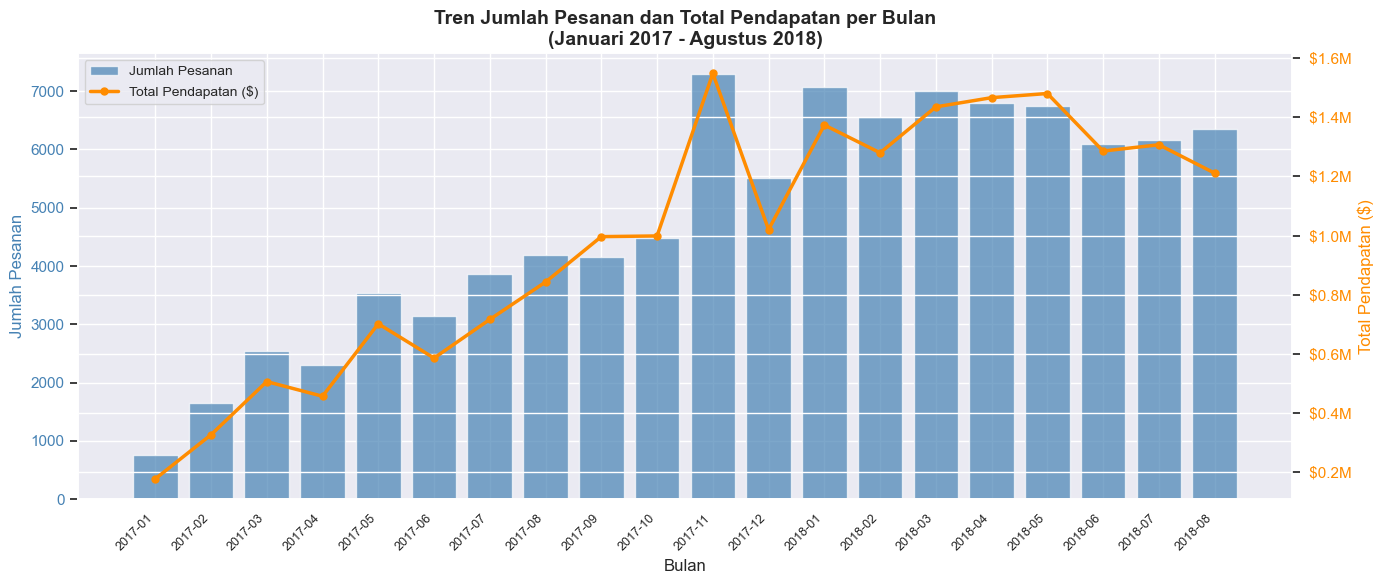

In [24]:
fig, ax1 = plt.subplots(figsize=(14, 6))

x = range(len(monthly_orders))
labels = monthly_orders['order_year_month'].tolist()

# Bar chart untuk jumlah pesanan
bars = ax1.bar(x, monthly_orders['total_order'], color='steelblue', alpha=0.7, label='Jumlah Pesanan')
ax1.set_xlabel('Bulan', fontsize=12)
ax1.set_ylabel('Jumlah Pesanan', fontsize=12, color='steelblue')
ax1.tick_params(axis='y', labelcolor='steelblue')
ax1.set_xticks(x)
ax1.set_xticklabels(labels, rotation=45, ha='right', fontsize=9)

# Line chart untuk pendapatan di axis kedua
ax2 = ax1.twinx()
ax2.plot(x, monthly_orders['total_pendapatan'], color='darkorange', marker='o',
         linewidth=2.5, markersize=5, label='Total Pendapatan ($)')
ax2.set_ylabel('Total Pendapatan ($)', fontsize=12, color='darkorange')
ax2.tick_params(axis='y', labelcolor='darkorange')
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f' ${x/1e6:.1f}M'))

# Legenda
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=10)

plt.title('Tren Jumlah Pesanan dan Total Pendapatan per Bulan\n(Januari 2017 - Agustus 2018)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

**Insight:**
- Berdasrkan grafik di atas, terdapat tren pertumbuhan yang kuat dari Januari 2017 hingga Agustus 2018.
- Lonjakan signifikan terjadi pada **November 2017** dengan total pesanan mencapai puncaknya.
- Pendapatan mengikuti pola yang sama dengan jumlah pesanan, namun dengan sedikit fluktuasi yang mencerminkan variasi nilai pesanan.

### Pertanyaan 2: Kategori produk apa yang menghasilkan volume penjualan dan pendapatan tertinggi selama periode 2017–2018?

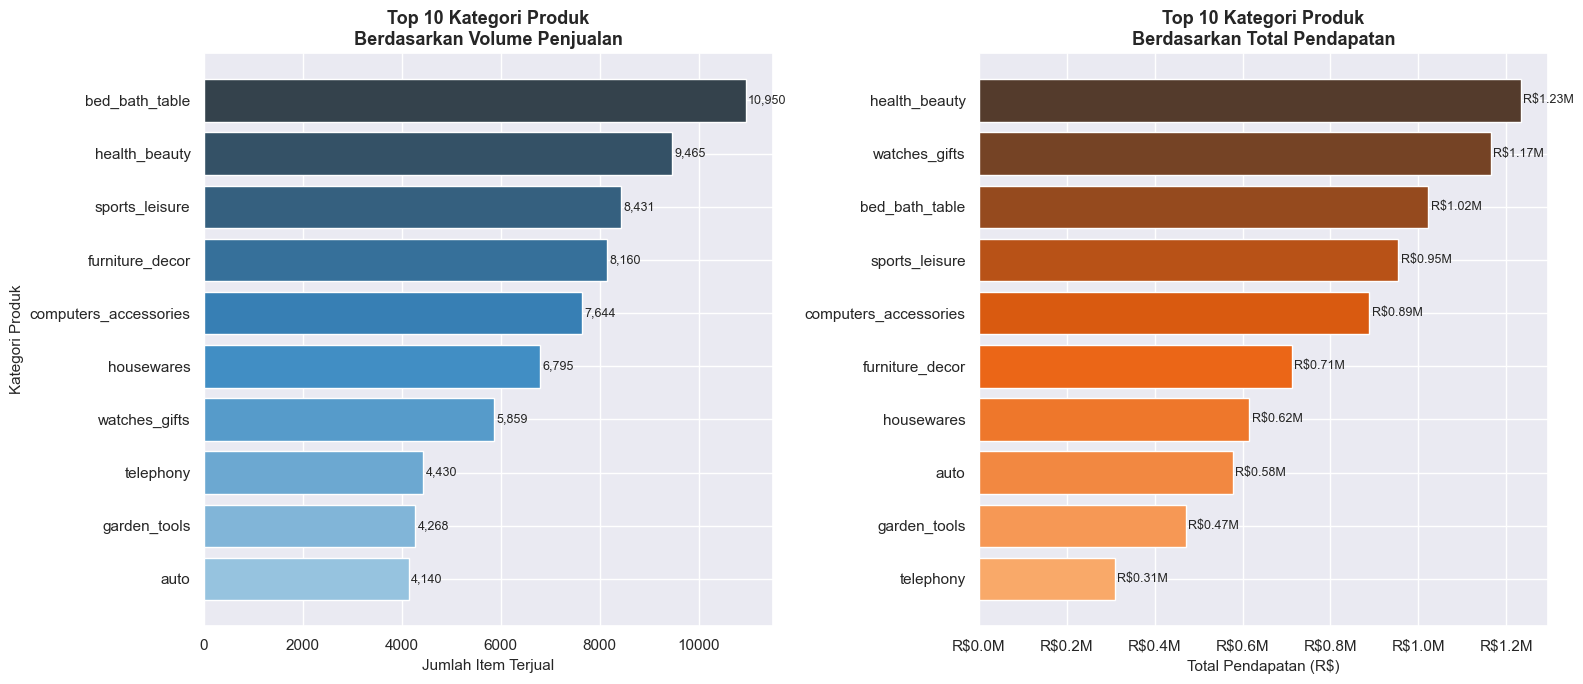

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Plot 1: Top 10 Kategori by Volume Penjualan
top10_qty = top_category.sort_values('total_item')
colors_qty = sns.color_palette('Blues_d', n_colors=len(top10_qty))
axes[0].barh(top10_qty['product_category_name'], top10_qty['total_item'],
             color=colors_qty)
axes[0].set_title('Top 10 Kategori Produk\nBerdasarkan Volume Penjualan', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Jumlah Item Terjual', fontsize=11)
axes[0].set_ylabel('Kategori Produk', fontsize=11)
for i, (val, name) in enumerate(zip(top10_qty['total_item'], top10_qty['product_category_name'])):
    axes[0].text(val + 50, i, f'{val:,}', va='center', fontsize=9)

#Plot 2: Top 10 Kategori by Pendapatan  
top10_rev = top_category.sort_values('total_pendapatan')
colors_rev = sns.color_palette('Oranges_d', n_colors=len(top10_rev))
axes[1].barh(top10_rev['product_category_name'], top10_rev['total_pendapatan'],
             color=colors_rev)
axes[1].set_title('Top 10 Kategori Produk\nBerdasarkan Total Pendapatan', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Total Pendapatan (R$)', fontsize=11)
axes[1].set_ylabel('')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'R${x/1e6:.1f}M'))
for i, val in enumerate(top10_rev['total_pendapatan']):
    axes[1].text(val + 5000, i, f'R${val/1e6:.2f}M', va='center', fontsize=9)

plt.tight_layout()
plt.show()

**Insight:**
- **bed_bath_table** menjadi kategori dengan volume penjualan tertinggi, menunjukkan tingginya permintaan produk rumah tangga.
- **health_beauty** dan **sports_leisure** konsisten berada di top 5 untuk kedua metrik, mencerminkan bagaimana gaya hidup konsumen.
- **health_beauty**, **watches_gifts**, dan **bed_bath_table** menyumbang total pendapatan tertinggi selama periode January 2017 - Agustus 2018.
- Terdapat perbedaan peringkat antara volume dan pendapatan: kategori seperti **watches_gifts** memiliki pendapatan tinggi meskipun volume tidak selalu tertinggi, menandakan harga rata-rata produk yang lebih mahal.

## Analisis Lanjutan

### A. RFM Analysis

RFM Analysis digunakan untuk mensegmentasi pelanggan berdasarkan tiga dimensi:
- **Recency (R)**: Seberapa baru pelanggan melakukan pembelian
- **Frequency (F)**: Seberapa sering pelanggan melakukan pembelian
- **Monetary (M)**: Seberapa besar total pengeluaran pelanggan

In [27]:
# Tentukan tanggal referensi (1 hari setelah tanggal transaksi terakhir)
reference_date = master_df['order_purchase_timestamp'].max() + pd.Timedelta(days=1)
print(f'Tanggal referensi: {reference_date.date()}')

# Hitung RFM per pelanggan unik
rfm_df = master_df.groupby('customer_unique_id').agg(
    Recency=('order_purchase_timestamp', lambda x: (reference_date - x.max()).days),
    Frequency=('order_id', 'nunique'),
    Monetary=('payment_value', 'sum')
).reset_index()

print(f'\nJumlah pelanggan unik: {len(rfm_df):,}')
rfm_df.describe()

Tanggal referensi: 2018-08-30

Jumlah pelanggan unik: 93,358


,Recency,Frequency,Monetary
count,93358.000000,93358.000000,93358.000000
mean,237.941773,1.033420,211.831449
std,152.591453,0.209097,642.163458
min,1.000000,1.000000,0.000000
25%,114.000000,1.000000,63.760000
50%,219.000000,1.000000,112.950000
75%,346.000000,1.000000,201.740000
max,714.000000,15.000000,109312.640000


In [28]:
# Recency: semakin kecil nilainya semakin baik (score 5)
rfm_df['R_Score'] = pd.qcut(rfm_df['Recency'], q=5, labels=[5, 4, 3, 2, 1])

# Frequency & Monetary: semakin besar nilainya semakin baik (score 5)
rfm_df['F_Score'] = pd.qcut(rfm_df['Frequency'].rank(method='first'), q=5, labels=[1, 2, 3, 4, 5])
rfm_df['M_Score'] = pd.qcut(rfm_df['Monetary'], q=5, labels=[1, 2, 3, 4, 5])

# RFM Score gabungan
rfm_df['RFM_Score'] = rfm_df['R_Score'].astype(str) + rfm_df['F_Score'].astype(str) + rfm_df['M_Score'].astype(str)
rfm_df['RFM_Total'] = rfm_df[['R_Score', 'F_Score', 'M_Score']].astype(int).sum(axis=1)

# Segmentasi pelanggan berdasarkan RFM Total Score
def rfm_segment(score):
    if score >= 13:
        return 'Champions'
    elif score >= 10:
        return 'Loyal Customers'
    elif score >= 7:
        return 'Potential Loyalist'
    elif score >= 5:
        return 'At Risk'
    else:
        return 'Lost Customers'

rfm_df['Segment'] = rfm_df['RFM_Total'].apply(rfm_segment)

# Distribusi segmen
segment_dist = rfm_df['Segment'].value_counts().reset_index()
segment_dist.columns = ['Segment', 'Count']
segment_dist['Percentage'] = (segment_dist['Count'] / len(rfm_df) * 100).round(1)
print('Distribusi Segmen RFM:')
segment_dist

Distribusi Segmen RFM:


,Segment,Count,Percentage
0,Potential Loyalist,38355,41.1
1,Loyal Customers,31586,33.8
2,At Risk,12301,13.2
3,Champions,7976,8.5
4,Lost Customers,3140,3.4


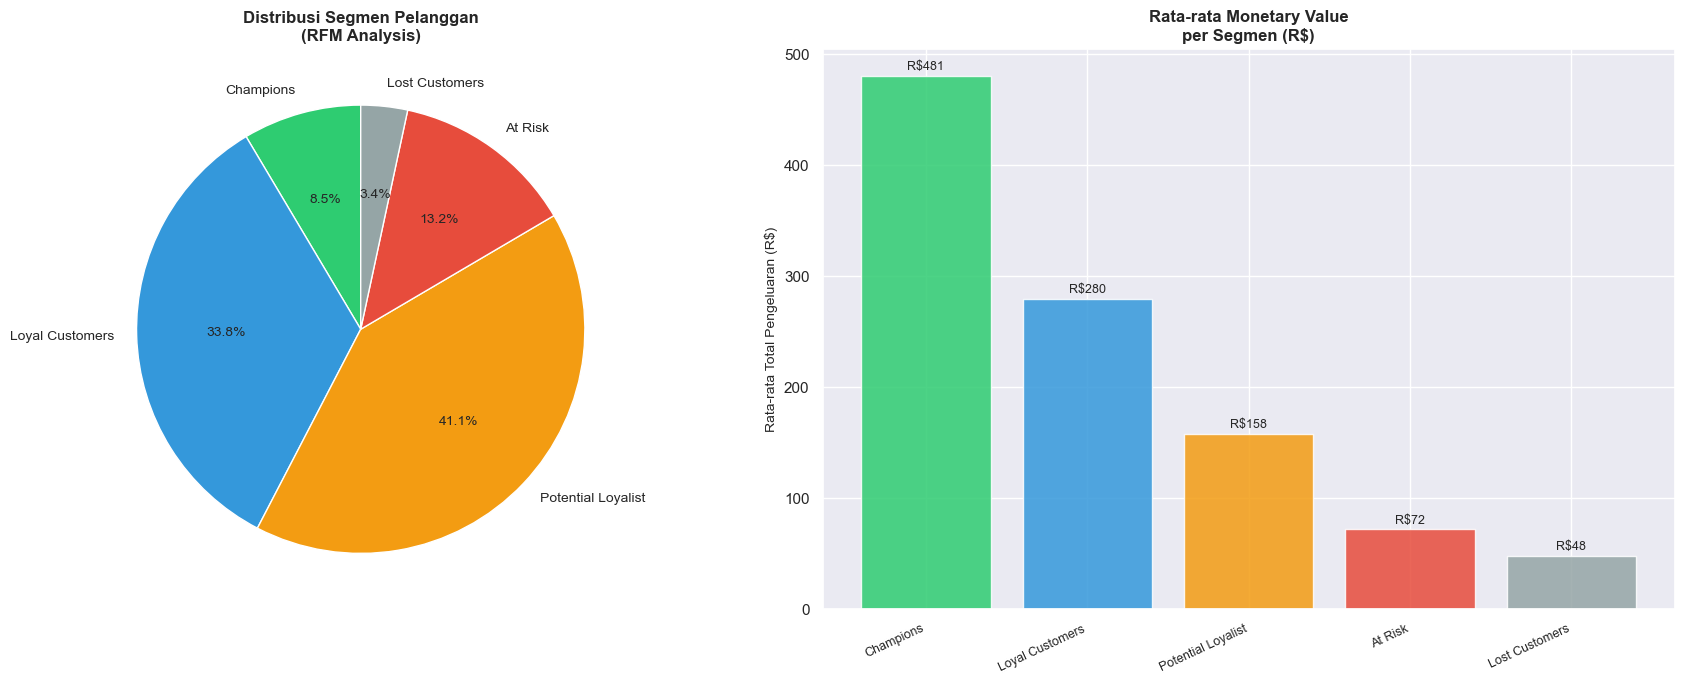

In [29]:
# Visualisasi RFM
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

segment_order = ['Champions', 'Loyal Customers', 'Potential Loyalist', 'At Risk', 'Lost Customers']
colors_rfm = ['#2ecc71', '#3498db', '#f39c12', '#e74c3c', '#95a5a6']
color_map = dict(zip(segment_order, colors_rfm))

# Plot 1: Distribusi Segmen menggunakan Pie Chart
seg_data = rfm_df['Segment'].value_counts().reindex(segment_order)
axes[0].pie(seg_data.values, labels=seg_data.index, autopct='%1.1f%%',
            colors=[color_map[s] for s in seg_data.index],
            startangle=90, textprops={'fontsize': 10})
axes[0].set_title('Distribusi Segmen Pelanggan\n(RFM Analysis)', fontsize=12, fontweight='bold')

# Plot 2: Rata-rata RFM per Segmen menggunakan Bar Chart
rfm_mean = rfm_df.groupby('Segment')[['Recency', 'Frequency', 'Monetary']].mean().reindex(segment_order)
x_seg = range(len(segment_order))
axes[1].bar(x_seg, rfm_mean['Monetary'], color=[color_map[s] for s in segment_order], alpha=0.85)
axes[1].set_xticks(x_seg)
axes[1].set_xticklabels(segment_order, rotation=25, ha='right', fontsize=9)
axes[1].set_title('Rata-rata Monetary Value\nper Segmen (R$)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Rata-rata Total Pengeluaran (R$)', fontsize=10)
for i, val in enumerate(rfm_mean['Monetary']):
    axes[1].text(i, val + 5, f'R${val:.0f}', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

**Insight RFM:**
- Sebagian besar pelanggan masuk dalam segmen **Potensial Loyalits** dan **Loyal Customers**, mengindikasikan tingginya tingkat pembelian berulang (repeat purchase rate).
- Segmen **Champions** memiliki rata-rata monetary value tertinggi, menunjukkan kontribusi besar terhadap pendapatan meskipun jumlahnya sedikit.
- Peluang besar ada pada segmen **At Risk** yang dapat ditingkatkan menjadi **Loyal Customers** melalui program loyalitas dan personalized marketing.

### B. Geospatial Analysis

Analisis geografis untuk memahami distribusi pelanggan dan penjual di seluruh wilayah Brazil.

In [30]:
# Merge koordinat ke data pelanggan
customers_geo = customers_df.merge(
    geolocation_clean,
    left_on='customer_zip_code_prefix',
    right_on='geolocation_zip_code_prefix',
    how='left'
).dropna(subset=['lat', 'lng'])

# Merge koordinat ke data penjual
sellers_geo = sellers_df.merge(
    geolocation_clean,
    left_on='seller_zip_code_prefix',
    right_on='geolocation_zip_code_prefix',
    how='left'
).dropna(subset=['lat', 'lng'])

print(f'Pelanggan dengan koordinat: {len(customers_geo):,}')
print(f'Penjual dengan koordinat  : {len(sellers_geo):,}')

Pelanggan dengan koordinat: 99,163
Penjual dengan koordinat  : 3,088


In [31]:
# Buat Heatmap menggunakan Folium
brazil_map = folium.Map(location=[-14.235, -51.9253], zoom_start=4,
                         tiles='CartoDB positron')

# Sample untuk performa
customers_sample = customers_geo[['lat', 'lng']].dropna().sample(min(5000, len(customers_geo)), random_state=42)
sellers_sample   = sellers_geo[['lat', 'lng']].dropna()

# Heatmap Pelanggan
HeatMap(
    customers_sample[['lat', 'lng']].values.tolist(),
    radius=8, blur=15, min_opacity=0.4,
    gradient={0.2: 'blue', 0.5: 'lime', 1: 'red'},
    name='Heatmap Pelanggan'
).add_to(brazil_map)

# Marker Penjual
seller_layer = folium.FeatureGroup(name='Lokasi Penjual')
for _, row in sellers_sample.iterrows():
    folium.CircleMarker(
        location=[row['lat'], row['lng']],
        radius=3, color='orange', fill=True, fill_opacity=0.6
    ).add_to(seller_layer)
seller_layer.add_to(brazil_map)

folium.LayerControl().add_to(brazil_map)


In [34]:
# Create images directory if it doesn't exist
os.makedirs('images', exist_ok=True)

# Now save the map
brazil_map.save('images/geospatial_map.html')
print('Peta berhasil disimpan sebagai geospatial_map.html')
brazil_map

Peta berhasil disimpan sebagai geospatial_map.html


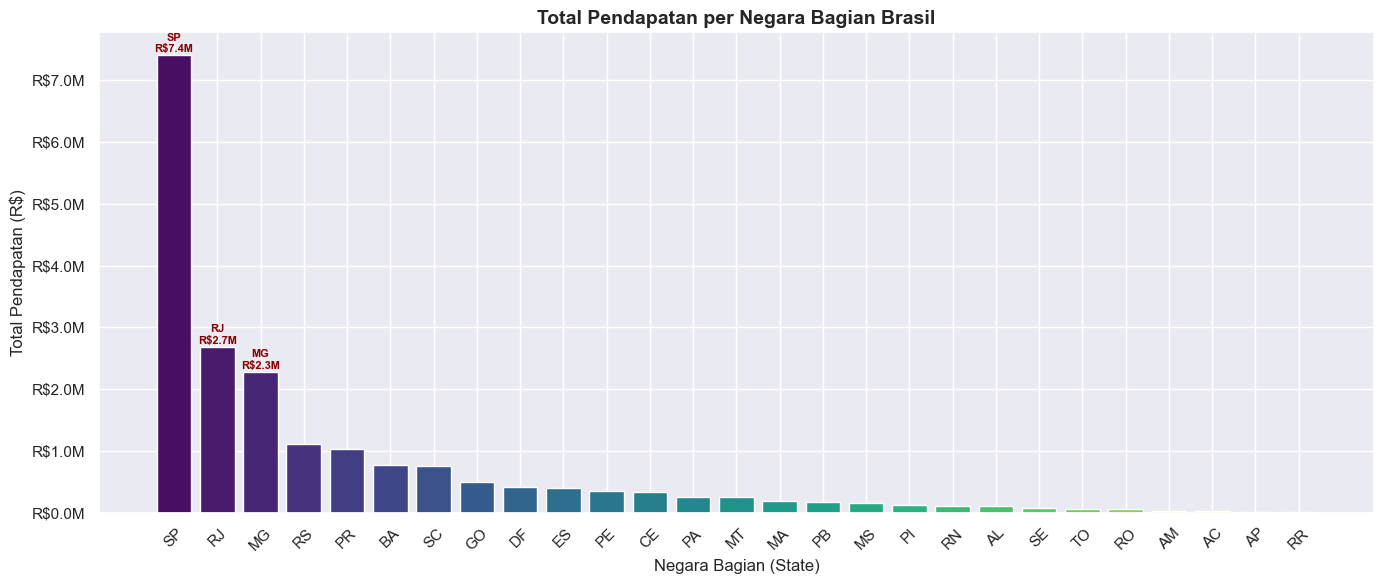

In [32]:
# Visualisasi statis: Revenue per State
revenue_by_state = master_df.groupby('customer_state').agg(
    total_orders=('order_id', 'nunique'),
    total_revenue=('payment_value', 'sum')
).reset_index().sort_values('total_revenue', ascending=False)

fig, ax = plt.subplots(figsize=(14, 6))
colors_state = sns.color_palette('viridis', n_colors=len(revenue_by_state))
ax.bar(revenue_by_state['customer_state'], revenue_by_state['total_revenue'],
       color=colors_state)
ax.set_title('Total Pendapatan per Negara Bagian Brasil', fontsize=14, fontweight='bold')
ax.set_xlabel('Negara Bagian (State)', fontsize=12)
ax.set_ylabel('Total Pendapatan (R$)', fontsize=12)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'R${x/1e6:.1f}M'))
plt.xticks(rotation=45)

# Anotasi top 3
for i, row in revenue_by_state.head(3).iterrows():
    idx = list(revenue_by_state['customer_state']).index(row['customer_state'])
    ax.text(idx, row['total_revenue'] + 50000,
            f"{row['customer_state']}\nR${row['total_revenue']/1e6:.1f}M",
            ha='center', fontsize=8, fontweight='bold', color='darkred')

plt.tight_layout()
plt.show()

**Insight Geospatial:**
- Konsentrasi pelanggan dan penjual sangat tinggi di wilayah tenggara Brazil, khususnya di negara bagian **São Paulo (SP)**, **Rio de Janeiro (RJ)**, dan **Minas Gerais (MG)**. 
- São Paulo menghasilkan pendapatan tertinggi, jauh melampaui negara bagian lainnya, mencerminkan peran kota ini sebagai pusat ekonomi Brazil. Berdasarkan grafik tersebut terlihat kesenjangan yang cukup besar antara negara bagian utara dan tenggara Brazil.
- Wilayah utara dan timur laut Brazil relatif sepi transaksi ini bisa menjadi celah untuk para pelaku ekonomi memperluas ekspansi pasar yang potensial.

### C. Clustering - Segmentasi Pelanggan berdasarkan Nilai Pesanan 

Metode clustering manual menggunakan **binning** untuk mengelompokkan pelanggan berdasarkan total pengeluaran dan frekuensi pembelian.

In [33]:
# Hitung total pengeluaran dan frekuensi per pelanggan
customer_cluster = master_df.groupby('customer_unique_id').agg(
    total_spend=('payment_value', 'sum'),
    total_orders=('order_id', 'nunique'),
    avg_order_value=('payment_value', 'mean')
).reset_index()

# Binning total_spend ke dalam 4 segmen
spend_bins   = [0, 100, 300, 700, float('inf')]
spend_labels = ['Low Spender\n(<R$100)', 'Medium Spender\n(R$100-300)',
                'High Spender\n(R$300-700)', 'VIP Spender\n(>R$700)']
customer_cluster['Spend_Segment'] = pd.cut(
    customer_cluster['total_spend'], bins=spend_bins, labels=spend_labels
)

# Binning frekuensi pembelian
freq_bins   = [0, 1, 2, 3, float('inf')]
freq_labels = ['One-Time Buyer', 'Occasional Buyer', 'Regular Buyer', 'Frequent Buyer']
customer_cluster['Freq_Segment'] = pd.cut(
    customer_cluster['total_orders'], bins=freq_bins, labels=freq_labels
)

print('Distribusi Spend Segment:')
display(customer_cluster['Spend_Segment'].value_counts())
print('\nDistribusi Frequency Segment:')
display(customer_cluster['Freq_Segment'].value_counts())

Distribusi Spend Segment:


Spend_Segment
Low Spender\n(<R$100)          41642
Medium Spender\n(R$100-300)    37676
High Spender\n(R$300-700)       9812
VIP Spender\n(>R$700)           4227
Name: count, dtype: int64


Distribusi Frequency Segment:


Freq_Segment
One-Time Buyer      90557
Occasional Buyer     2573
Regular Buyer         181
Frequent Buyer         47
Name: count, dtype: int64

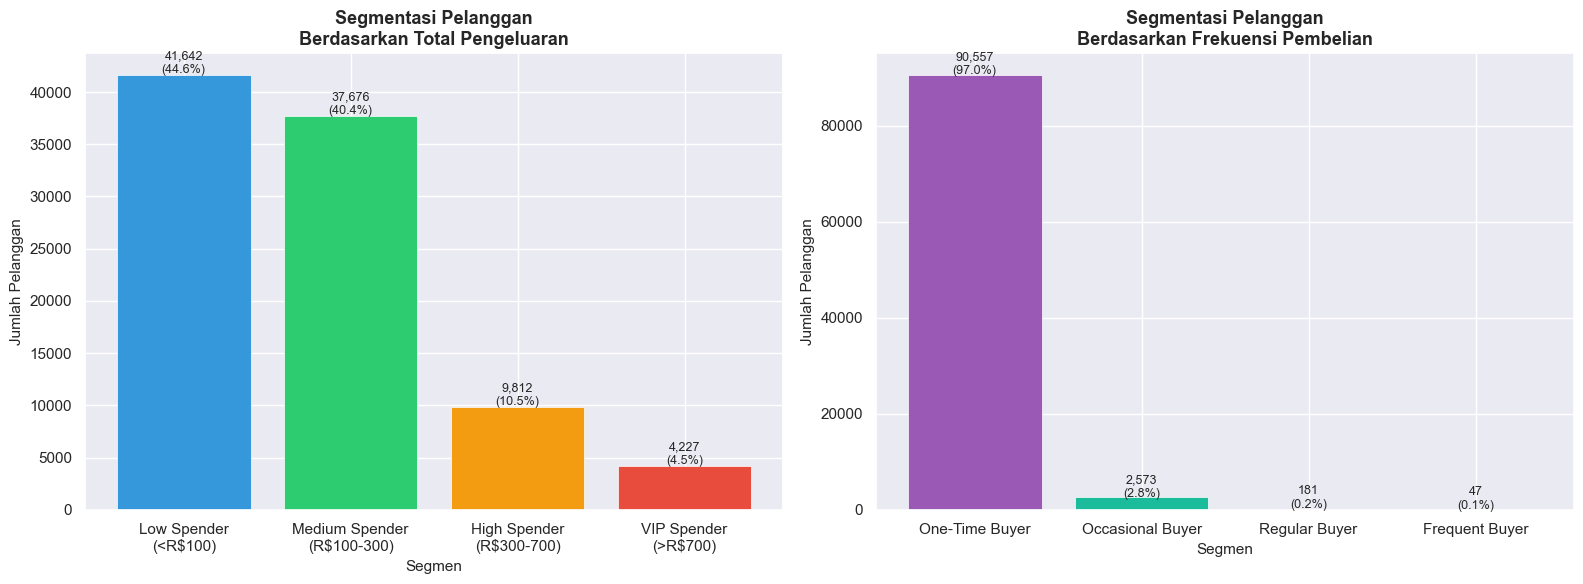

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Distribusi Spend Segment
spend_dist = customer_cluster['Spend_Segment'].value_counts()
colors_spend = ['#3498db', '#2ecc71', '#f39c12', '#e74c3c']
axes[0].bar(spend_dist.index, spend_dist.values, color=colors_spend, edgecolor='white', linewidth=0.5)
axes[0].set_title('Segmentasi Pelanggan\nBerdasarkan Total Pengeluaran', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Segmen', fontsize=11)
axes[0].set_ylabel('Jumlah Pelanggan', fontsize=11)
for i, (label, val) in enumerate(zip(spend_dist.index, spend_dist.values)):
    pct = val / len(customer_cluster) * 100
    axes[0].text(i, val + 200, f'{val:,}\n({pct:.1f}%)', ha='center', fontsize=9)

# Plot 2: Distribusi Frequency Segment
freq_dist = customer_cluster['Freq_Segment'].value_counts()
colors_freq = ['#9b59b6', '#1abc9c', '#e67e22', '#c0392b']
axes[1].bar(freq_dist.index, freq_dist.values, color=colors_freq, edgecolor='white', linewidth=0.5)
axes[1].set_title('Segmentasi Pelanggan\nBerdasarkan Frekuensi Pembelian', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Segmen', fontsize=11)
axes[1].set_ylabel('Jumlah Pelanggan', fontsize=11)
for i, (label, val) in enumerate(zip(freq_dist.index, freq_dist.values)):
    pct = val / len(customer_cluster) * 100
    axes[1].text(i, val + 200, f'{val:,}\n({pct:.1f}%)', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

**Insight Clustering:**
- Sekitar 42% pelanggan masuk kategori **Low Spender** dengan total belanja di bawah $100, mengindikasikan rata-rata nilai transaksi yang relatif rendah.
- Lebih dari 90% pelanggan adalah **One-Time Buyer**, hal ini menjadi tantangan utama bisnis dalam meningkatkan retention rate.
- Segmen **VIP Spender** meskipun kecil jumlahnya, tetapi mampu berkontribusi signifikan terhadap total pendapatan dan perlu mendapatkan perhatian khusus melalui program eksklusif.

## Conclusion

### Kesimpulan Pertanyaan 1:
Tren pesanan dan pendapatan E-Commerce menunjukkan **pertumbuhan yang konsisten** sepanjang periode Januari 2017 hingga Agustus 2018. Lonjakan paling signifikan terjadi pada bulan **November 2017** sehingga fenomena ini memiliki dampak besar terhadap volume transaksi. Para pelaku bisnis disarankan untuk memaksimalkan strategi promosi pada periode akhir tahun (Q4) setiap tahunnya.

### Kesimpulan Pertanyaan 2:
Kategori **bed_bath_table**, **health_beauty**, dan **sports_leisure** secara konsisten mendominasi volume penjualan. Sementara dari sisi pendapatan, kategori **wathces_gifts** dan **health_beauty** menghasilkan nilai tertinggi. Artinya pelaku bisnis sebaiknya mengalokasikan lebih banyak inventaris dan anggaran promosi pada kategori-kategori ini untuk memaksimalkan pendapatan.

### Kesimpulan Analisis Lanjutan:
- **RFM Analysis**: Sebagian besar pelanggan masuk dalam segmen **Potensial Loyalits** dan **Loyal Customers**. Diperlukan strategi retensi seperti email remarketing, diskon loyalitas, dan program referral untuk mengkonversi segmen ini menjadi pelanggan **Champions**.
- **Geospatial Analysis**: Konsentrasi bisnis terpusat di kawasan tenggara Brazil (SP, RJ, MG). Ekspansi ke wilayah utara dan timur laut merupakan peluang pertumbuhan bisnis yang belum dioptimalkan.
- **Clustering**: Dengan >90% pelanggan adalah one-time buyer, program loyalitas dan personalized recommendation menjadi prioritas utama untuk meningkatkan customer lifetime value.